# 딥러닝-클래스 선언 방식

FashionMNIST 데이터를 사용해 CNN 모델을 `nn.Sequential` 방식과 `nn.Module` 클래스로 선언하는 방식을 비교합니다.

이 노트북의 목표는 다음과 같습니다.

- `nn.Sequential`로 간단한 모델을 선언한다.
- `nn.Module`을 상속한 클래스로 모델 구조를 선언한다.
- `__init__()`에서 layer를 정의하고 `forward()`에서 연산 흐름을 작성한다.
- 같은 구조의 모델을 기존 방식과 클래스 방식으로 각각 구현한다.

## 1. 환경 준비

필요한 라이브러리를 불러오고, 반복해서 사용할 함수들을 먼저 정의합니다.

### 1.1 라이브러리 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor

- 모델 요약 도구
    - `torchsummary`가 설치되어 있으면 모델 구조와 파라미터 수를 확인할 수 있습니다.

In [ ]:
# 설치가 필요한 경우 라이브러리 설치합니다.
# %pip install torchsummary

In [ ]:
from torchsummary import summary

### 1.2 필요 함수 생성

아래 함수들이 학습 흐름의 핵심입니다.

- `make_DataSet`: numpy/pandas 데이터를 학습용 `DataLoader`와 검증 텐서로 변환합니다.
- `train`: 한 epoch 동안 미니배치 학습을 수행합니다.
- `evaluate`: 검증 또는 테스트 데이터 전체에 대해 손실과 예측값을 반환합니다.
- `dl_learning_curve`: train loss, validation loss, validation accuracy를 시각화합니다.

- `make_DataSet` 함수 : 딥러닝을 위한 데이터로더 만들기

In [ ]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(np.array(x_train), dtype=torch.float32)
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
    x_val_tensor = torch.tensor(np.array(x_val), dtype=torch.float32)
    y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor

- `train` 함수 : 학습을 위한 함수

In [ ]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""

    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Feed Forward
        optimizer.zero_grad()              # 이전 배치의 gradient를 초기화
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()                    # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()                   # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)  # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적

    return total_loss / len(dataloader.dataset)  # 전체 데이터 개수로 나누어 epoch 평균 loss 반환

- `evaluate` 함수 : 검증을 위한 함수

In [ ]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증/테스트 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()  # 모델을 평가 모드로 설정

    with torch.no_grad():  # 평가 과정에서는 기울기를 계산하지 않음
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

- 학습 곡선

In [ ]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.plot(epochs, val_acc_list, label="val_acc", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss / Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

- 예측 결과 변환 함수

In [ ]:
def predict_class(pred):
    """모델 출력(logits)을 최종 클래스 번호로 변환합니다."""

    pred_prob = nn.functional.softmax(pred, dim=1)
    return np.argmax(pred_prob.cpu().numpy(), axis=1)

- 모델 평가 함수

In [ ]:
def evaluate_report(x_test, y_test, model, loss_fn, device, classes):
    """테스트 데이터 예측 후 confusion matrix와 classification report를 출력합니다."""

    _, pred = evaluate(x_test, y_test, model, loss_fn, device)
    pred = predict_class(pred)

    cm = confusion_matrix(y_test.numpy(), pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot()
    plt.xticks(rotation=90)
    plt.show()

    print("=" * 80)
    print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
    print("-" * 80)
    print(classification_report(y_test.numpy(), pred, target_names=classes))

    return pred

### 1.3 Device 준비

GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### 1.4 데이터 셋
- FashionMNIST 데이터 사용
    - 여러 실험을 빠르게 수행하기 위해 원본 데이터에서 일부만 샘플링

- 데이터 다운로드

In [ ]:
train_dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 277kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.11MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]


- 데이터 축소


In [ ]:
# 데이터와 레이블 추출
train_data = train_dataset.data.numpy() / 255
train_labels = train_dataset.targets.numpy()
test_data = test_dataset.data.numpy() / 255
test_labels = test_dataset.targets.numpy()

# 데이터 샘플링, 층화추출
x_train, _, y_train, _ = train_test_split(
    train_data,
    train_labels,
    test_size=40000,
    random_state=10,
    stratify=train_labels
)
x_val, x_test, y_val, y_test = train_test_split(
    test_data,
    test_labels,
    test_size=5000,
    random_state=10,
    stratify=test_labels
)

# 3차원 데이터를 CNN 입력 형태인 4차원으로 변환
x_train = x_train.reshape(20000, 1, 28, 28)
x_val = x_val.reshape(5000, 1, 28, 28)
x_test = x_test.reshape(5000, 1, 28, 28)

# tensor로 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# train_dataset으로 변환
train_TensorDS = TensorDataset(x_train, y_train)

- y(target)의 클래스

In [ ]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

- train은 DataLoader로 생성

In [ ]:
batch_size = 64
train_dataloader = DataLoader(train_TensorDS, batch_size=batch_size, shuffle=True)

In [ ]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_dataloader:
    print(f"Shape of x [batch, channels, height, width]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


## 2. 모델링

- 같은 CNN 구조를 두 가지 방식으로 선언합니다.

    - 기존 방식: `nn.Sequential`로 layer를 순서대로 쌓기
    - 클래스 방식: `nn.Module`을 상속받아 `__init__()`과 `forward()`를 직접 작성하기

### 2.1 기존 방식: nn.Sequential

- `nn.Sequential`은 순차적인 layer를 빠르게 쌓을 때 편리
- 모델 구조가 단순하고 흐름이 일직선일 때 코드 간결

- 모델 선언

In [ ]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(4 * 14 * 14, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
           Flatten-4                  [-1, 784]               0
            Linear-5                   [-1, 10]           7,850
Total params: 7,890
Trainable params: 7,890
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.03
Estimated Total Size (MB): 0.09
----------------------------------------------------------------


- 학습

Epoch 1, train loss : 0.9016, val loss : 0.6676, val acc : 0.7496
Epoch 2, train loss : 0.5639, val loss : 0.5517, val acc : 0.8070
Epoch 3, train loss : 0.5058, val loss : 0.5143, val acc : 0.8196
Epoch 4, train loss : 0.4814, val loss : 0.5032, val acc : 0.8234
Epoch 5, train loss : 0.4524, val loss : 0.4745, val acc : 0.8376
Epoch 6, train loss : 0.4190, val loss : 0.4490, val acc : 0.8432
Epoch 7, train loss : 0.4006, val loss : 0.4399, val acc : 0.8468
Epoch 8, train loss : 0.3875, val loss : 0.4297, val acc : 0.8484
Epoch 9, train loss : 0.3778, val loss : 0.4182, val acc : 0.8564
Epoch 10, train loss : 0.3680, val loss : 0.4098, val acc : 0.8574


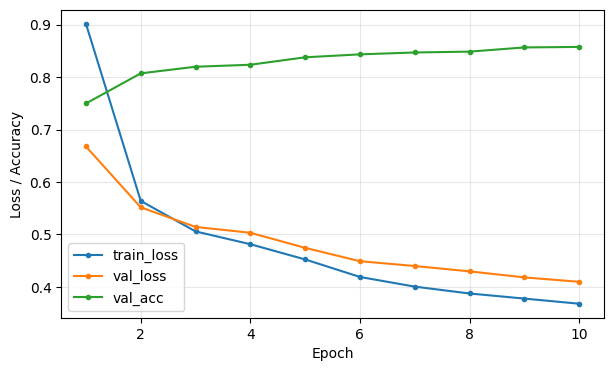

In [ ]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

- 모델 평가

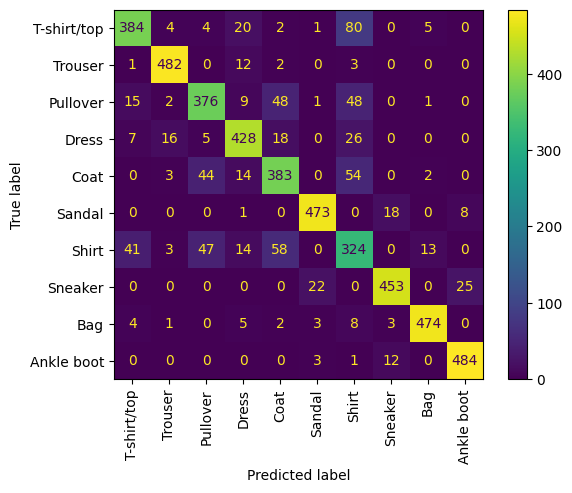

Accuracy : 0.8522
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.77      0.81       500
     Trouser       0.94      0.96      0.95       500
    Pullover       0.79      0.75      0.77       500
       Dress       0.85      0.86      0.85       500
        Coat       0.75      0.77      0.76       500
      Sandal       0.94      0.95      0.94       500
       Shirt       0.60      0.65      0.62       500
     Sneaker       0.93      0.91      0.92       500
         Bag       0.96      0.95      0.95       500
  Ankle boot       0.94      0.97      0.95       500

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



In [ ]:
pred = evaluate_report(x_test, y_test, model, loss_fn, device, classes)

### 2.2 클래스 방식: nn.Module

- `nn.Module`을 상속하면 모델 구조를 더 유연하게 작성할 수 있습니다.

    - `__init__()` : 사용할 layer 정의
    - `forward()` : 입력 데이터가 layer를 통과하는 순서 정의
    - 조건문, 반복문, 다중 입력 등 복잡한 연산이 필요한 경우 클래스 방식이 더 적합

- 클래스 생성

In [ ]:
class CustomCNN(nn.Module):                             # PyTorch의 기본 클래스인 nn.Module을 상속받음
    def __init__(self, n_class):                        # 클래스가 인스턴스화 될 때 호출되는 초기 메서드, 모델 구조와 파라미터 정의
        super(CustomCNN, self).__init__()

        # 필요한 레이어 정의(초기화)
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)        # 합성곱 레이어
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)       # 맥스 풀링
        self.flatten = nn.Flatten()                             # 데이터를 2차원 벡터로 변환하는 레이어
        self.fc1 = nn.Linear(4 * 14 * 14, n_class)              # Fully connected 레이어

    def forward(self, x):
        # 모델 설계
        x = self.conv1(x)           # 합성곱 연산 적용
        x = self.relu(x)            # 활성화 함수
        x = self.pool(x)            # 풀링 연산 적용
        x = self.flatten(x)         # 1차원 벡터로 변환
        x = self.fc1(x)             # 최종 클래스 출력
        return x

- 모델 선언

In [ ]:
n_class = 10
model = CustomCNN(n_class).to(device)

In [ ]:
# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [ ]:
# 모델 요약
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
           Flatten-4                  [-1, 784]               0
            Linear-5                   [-1, 10]           7,850
Total params: 7,890
Trainable params: 7,890
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.03
Estimated Total Size (MB): 0.09
----------------------------------------------------------------


- 학습

Epoch 1, train loss : 0.8290, val loss : 0.5621, val acc : 0.8000
Epoch 2, train loss : 0.4985, val loss : 0.4921, val acc : 0.8250
Epoch 3, train loss : 0.4471, val loss : 0.4521, val acc : 0.8390
Epoch 4, train loss : 0.4206, val loss : 0.4739, val acc : 0.8266
Epoch 5, train loss : 0.4069, val loss : 0.4254, val acc : 0.8512
Epoch 6, train loss : 0.3954, val loss : 0.4298, val acc : 0.8510
Epoch 7, train loss : 0.3825, val loss : 0.4182, val acc : 0.8494
Epoch 8, train loss : 0.3767, val loss : 0.4309, val acc : 0.8542
Epoch 9, train loss : 0.3699, val loss : 0.4108, val acc : 0.8596
Epoch 10, train loss : 0.3640, val loss : 0.4008, val acc : 0.8614


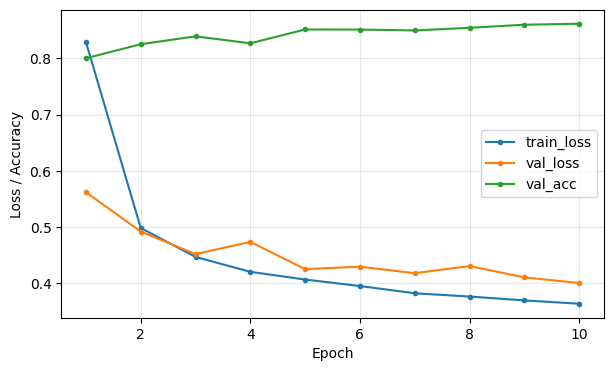

In [ ]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

- 모델 평가

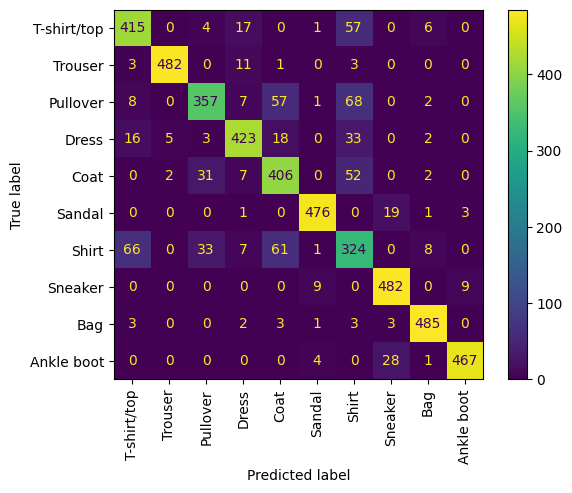

Accuracy : 0.8634
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.83      0.82       500
     Trouser       0.99      0.96      0.97       500
    Pullover       0.83      0.71      0.77       500
       Dress       0.89      0.85      0.87       500
        Coat       0.74      0.81      0.78       500
      Sandal       0.97      0.95      0.96       500
       Shirt       0.60      0.65      0.62       500
     Sneaker       0.91      0.96      0.93       500
         Bag       0.96      0.97      0.96       500
  Ankle boot       0.97      0.93      0.95       500

    accuracy                           0.86      5000
   macro avg       0.87      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000



In [ ]:
pred = evaluate_report(x_test, y_test, model, loss_fn, device, classes)

---

## 3. 실습

- 기존 방식으로 작성된 CNN 모델을 클래스 방식으로 바꿔 봅니다.

### 3.1 실습 1

#### 3.1.1 기존 모델 설계

In [ ]:
n_class = 10

# 모델 구조 설계
model2 = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(8 * 7 * 7, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

# 모델 요약
summary(model2, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
            Conv2d-4            [-1, 8, 14, 14]             296
              ReLU-5            [-1, 8, 14, 14]               0
         MaxPool2d-6              [-1, 8, 7, 7]               0
           Flatten-7                  [-1, 392]               0
            Linear-8                   [-1, 10]           3,930
Total params: 4,266
Trainable params: 4,266
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.02
Estimated Total Size (MB): 0.10
----------------------------------------------------------------


#### 3.1.2 클래스 방식

- 클래스 생성

In [ ]:
class CustomCNNPractice1(nn.Module):                             # PyTorch의 기본 클래스인 nn.Module을 상속받음
    def __init__(self, n_class):
        super(CustomCNNPractice1, self).__init__()           # 클래스명과 일치해야 함

        # 실습 1 모델 구조 설계
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        # MaxPool을 두 번 거치면 28x28 -> 14x14 -> 7x7 이 됩니다.
        self.fc1 = nn.Linear(8 * 7 * 7, n_class)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return x

- 모델 선언

In [ ]:
n_class = 10
model2 = CustomCNNPractice1(n_class).to(device)

# loss. optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

summary(model2, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
            Conv2d-4            [-1, 8, 14, 14]             296
              ReLU-5            [-1, 8, 14, 14]               0
         MaxPool2d-6              [-1, 8, 7, 7]               0
           Flatten-7                  [-1, 392]               0
            Linear-8                   [-1, 10]           3,930
Total params: 4,266
Trainable params: 4,266
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.02
Estimated Total Size (MB): 0.10
----------------------------------------------------------------


- 학습

Epoch 1, train loss : 1.0307, val loss : 0.6440, val acc : 0.7478
Epoch 2, train loss : 0.5480, val loss : 0.5404, val acc : 0.7878
Epoch 3, train loss : 0.4852, val loss : 0.4784, val acc : 0.8252
Epoch 4, train loss : 0.4513, val loss : 0.4564, val acc : 0.8328
Epoch 5, train loss : 0.4256, val loss : 0.4485, val acc : 0.8348
Epoch 6, train loss : 0.4088, val loss : 0.4413, val acc : 0.8416
Epoch 7, train loss : 0.3971, val loss : 0.4108, val acc : 0.8510
Epoch 8, train loss : 0.3836, val loss : 0.4083, val acc : 0.8488
Epoch 9, train loss : 0.3757, val loss : 0.4231, val acc : 0.8476
Epoch 10, train loss : 0.3647, val loss : 0.3935, val acc : 0.8570


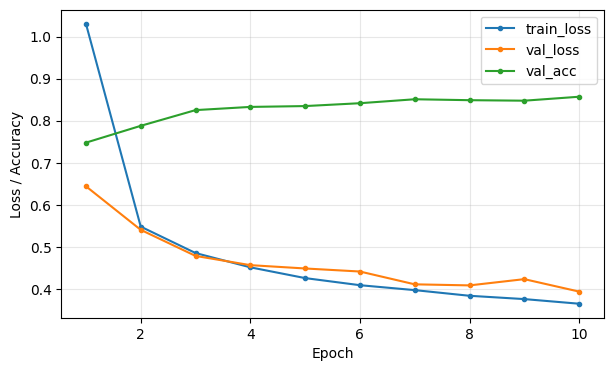

In [ ]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model2, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model2, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

- 모델 평가

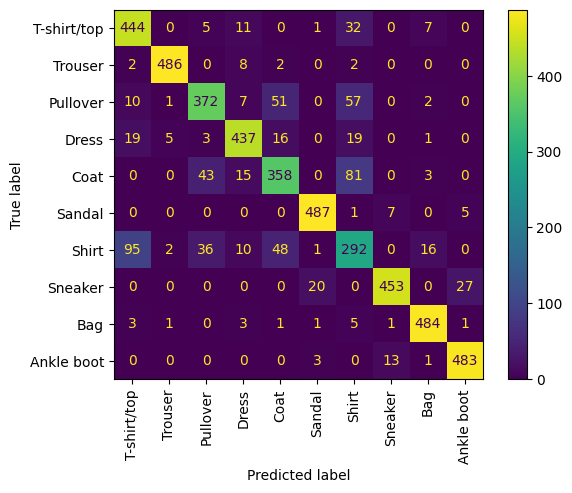

Accuracy : 0.8592
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.89      0.83       500
     Trouser       0.98      0.97      0.98       500
    Pullover       0.81      0.74      0.78       500
       Dress       0.89      0.87      0.88       500
        Coat       0.75      0.72      0.73       500
      Sandal       0.95      0.97      0.96       500
       Shirt       0.60      0.58      0.59       500
     Sneaker       0.96      0.91      0.93       500
         Bag       0.94      0.97      0.95       500
  Ankle boot       0.94      0.97      0.95       500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



In [ ]:
pred = evaluate_report(x_test, y_test, model2, loss_fn, device, classes)

### 3.2 실습 2

#### 3.2.1 기존 모델 설계

In [ ]:
n_class = 10

# 모델 구조 설계
model3 = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(8 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001)

# 모델 요약
summary(model3, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
            Conv2d-4            [-1, 8, 14, 14]             296
              ReLU-5            [-1, 8, 14, 14]               0
         MaxPool2d-6              [-1, 8, 7, 7]               0
           Flatten-7                  [-1, 392]               0
            Linear-8                  [-1, 128]          50,304
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 51,930
Trainable params: 51,930
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.09
Params size (MB): 0.20
Estimated Tot

#### 3.2.2 클래스 방식

- 클래스 생성

In [ ]:
class CustomCNNPractice2(nn.Module):                             # PyTorch의 기본 클래스인 nn.Module을 상속받음
    def __init__(self, n_class):
        super(CustomCNNPractice1, self).__init__()           # 클래스명과 일치해야 함

        # 실습 1 모델 구조 설계
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        # MaxPool을 두 번 거치면 28x28 -> 14x14 -> 7x7 이 됩니다.
        self.fc1 = nn.Linear(8 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, n_class)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

- 모델 선언

In [ ]:
n_class = 10
model3 = CustomCNNPractice1(n_class).to(device)

# loss. optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001)

summary(model3, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
            Conv2d-4            [-1, 8, 14, 14]             296
              ReLU-5            [-1, 8, 14, 14]               0
         MaxPool2d-6              [-1, 8, 7, 7]               0
           Flatten-7                  [-1, 392]               0
            Linear-8                   [-1, 10]           3,930
Total params: 4,266
Trainable params: 4,266
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.02
Estimated Total Size (MB): 0.10
----------------------------------------------------------------


- 학습

Epoch 1, train loss : 0.9058, val loss : 0.6235, val acc : 0.7690
Epoch 2, train loss : 0.5489, val loss : 0.5652, val acc : 0.7920
Epoch 3, train loss : 0.4810, val loss : 0.4815, val acc : 0.8254
Epoch 4, train loss : 0.4455, val loss : 0.4656, val acc : 0.8310
Epoch 5, train loss : 0.4256, val loss : 0.4425, val acc : 0.8406
Epoch 6, train loss : 0.4146, val loss : 0.4312, val acc : 0.8464
Epoch 7, train loss : 0.4011, val loss : 0.4235, val acc : 0.8508
Epoch 8, train loss : 0.3874, val loss : 0.4176, val acc : 0.8546
Epoch 9, train loss : 0.3775, val loss : 0.4260, val acc : 0.8502
Epoch 10, train loss : 0.3725, val loss : 0.3889, val acc : 0.8620


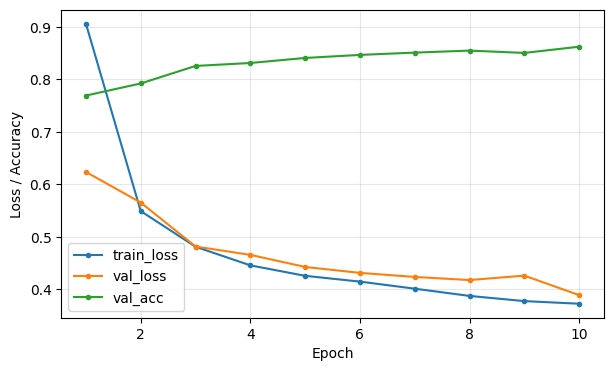

In [ ]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model3, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model3, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

- 모델 평가

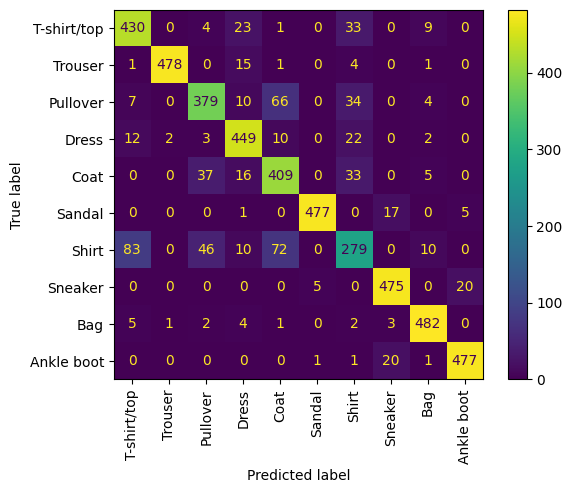

Accuracy : 0.867
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.86      0.83       500
     Trouser       0.99      0.96      0.97       500
    Pullover       0.80      0.76      0.78       500
       Dress       0.85      0.90      0.87       500
        Coat       0.73      0.82      0.77       500
      Sandal       0.99      0.95      0.97       500
       Shirt       0.68      0.56      0.61       500
     Sneaker       0.92      0.95      0.94       500
         Bag       0.94      0.96      0.95       500
  Ankle boot       0.95      0.95      0.95       500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



In [ ]:
pred = evaluate_report(x_test, y_test, model3, loss_fn, device, classes)